In [2]:
import numpy as np
import scipy.stats as st
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('spotify.csv')
df

,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.7150,87.917,4,acoustic
1,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.2670,77.489,4,acoustic
2,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.1200,76.332,4,acoustic
3,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.1430,181.740,3,acoustic
4,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.1670,119.949,4,acoustic
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113995,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Sleep My Little Boy,21,384999,False,0.172,0.2350,5,-16.393,1,0.0422,0.6400,0.928000,0.0863,0.0339,125.995,5,world-music
113996,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Water Into Light,22,385000,False,0.174,0.1170,0,-18.318,0,0.0401,0.9940,0.976000,0.1050,0.0350,85.239,4,world-music
113997,Cesária Evora,Best Of,Miss Perfumado,22,271466,False,0.629,0.3290,0,-10.895,0,0.0420,0.8670,0.000000,0.0839,0.7430,132.378,4,world-music
113998,Michael W. Smith,Change Your World,Friends,41,283893,False,0.587,0.5060,7,-10.889,1,0.0297,0.3810,0.000000,0.2700,0.4130,135.960,4,world-music


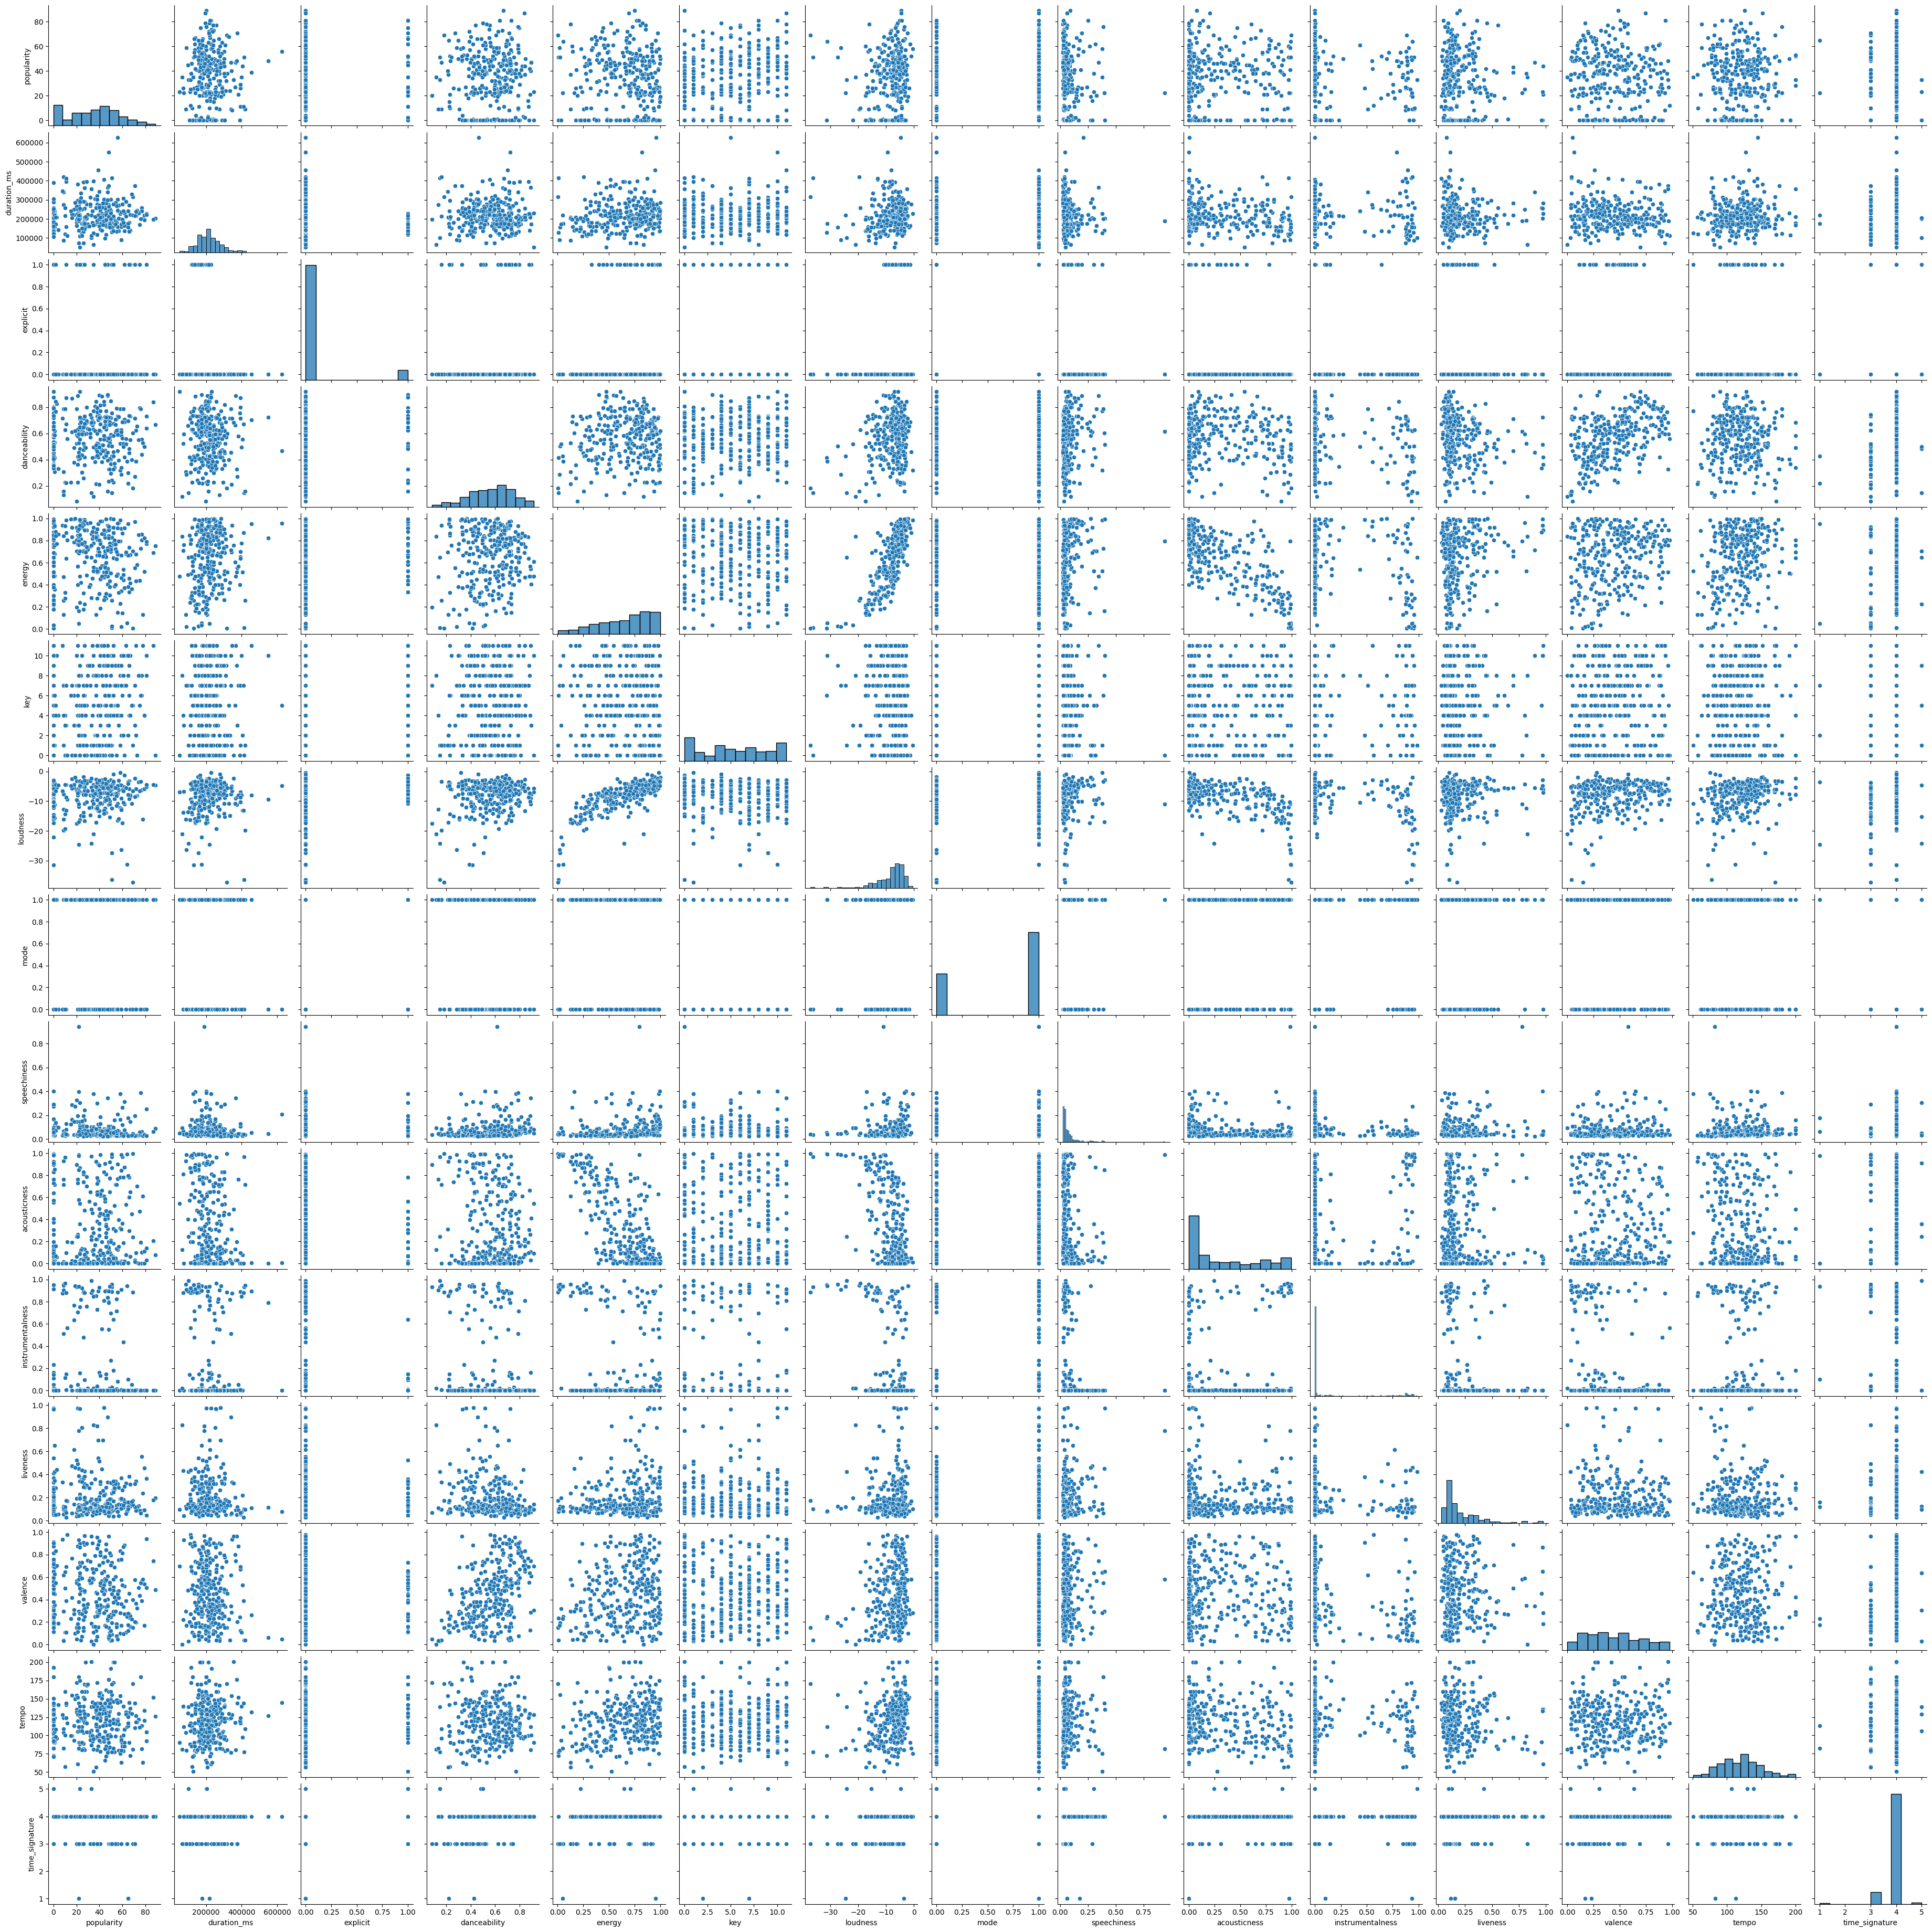

In [4]:
sns.pairplot(df.sample(n=300))

In [5]:

corrcoef_table = df[["popularity","duration_ms","danceability","energy","loudness","speechiness","acousticness","liveness","valence","tempo"]].corr()

strong_corr = corrcoef_table.where((corrcoef_table > 0.6) | (corrcoef_table < -0.6))
strong_corr

,popularity,duration_ms,danceability,energy,loudness,speechiness,acousticness,liveness,valence,tempo
popularity,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
duration_ms,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
danceability,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
energy,NaN,NaN,NaN,1.000000,0.76169,NaN,-0.733906,NaN,NaN,NaN
loudness,NaN,NaN,NaN,0.761690,1.00000,NaN,NaN,NaN,NaN,NaN
speechiness,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN
acousticness,NaN,NaN,NaN,-0.733906,NaN,NaN,1.000000,NaN,NaN,NaN
liveness,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN
valence,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN
tempo,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0


from this table , we can see that the only values that have a supposed correlation are :
energy/loudness & energy/acousticnesss –––––––––––– So we'll keep those 

### Data cleaning time, were only going to keep the track info and two categorical and three numerical variables 
here we decided to chose :
#### 3 numerical continuous variables
- **energy** : Energy is a measure from 0.0 to 1.0 and represents a perceptual measure of intensity and activity. Typically, energetic tracks feel fast, loud, and noisy. For example, death metal has high energy, while a Bach prelude scores low on the scale

- **loudness** : The overall loudness of a track in decibels (dB)

- **acousticness** : A confidence measure from 0.0 to 1.0 of whether the track is acoustic. 1.0 represents high confidence the track is acoustic

#### 2 categorical variables
- **key** : The key the track is in. Integers map to pitches using standard Pitch Class notation. E.g. 0 = C, 1 = C♯/D♭, 2 = D, and so on. If no key was detected, the value is -1

- **track_genre** : The genre in which the track belongs


--- *source : kaggle description of the dataset* ---

### Making the dataset less big 
we have a little problem , if we try to find correlations right now we encounter 2 subproblems :
1. Because there is 114k rows the calculations are very costly
2. Because there are so much values if we plot anything we will not be able to see any correlation

SO we sample n = 1000

In [6]:
spotify = df[["artists","album_name","track_name","energy","loudness","acousticness","key","track_genre"]]
spotify = spotify.sample(n=1000) 
spotify = spotify.reset_index()
spotify = spotify.drop("index",axis=1)
spotify

,artists,album_name,track_name,energy,loudness,acousticness,key,track_genre
0,Whitechapel,The Valley,Hickory Creek,0.712,-6.818,0.003180,11,metalcore
1,Debbies,Comfort Zone,Comfort Zone,0.782,-4.231,0.000753,1,garage
2,Tunacola,Todos los Veranos del Mundo,Guachita,0.655,-6.112,0.518000,3,electronic
3,The Shins,Home For Christmas 2022,Wonderful Christmastime,0.689,-5.406,0.010900,11,indie-pop
4,Pinkfong,Pinkfong & Baby Shark Halloween Zombi,Boda de Sirenas en Halloween,0.557,-5.317,0.286000,7,children
...,...,...,...,...,...,...,...,...
995,Emily Nash;Olivia Sebastianelli,Chemical Embrace,Chemical Embrace,0.678,-6.442,0.007910,7,groove
996,The Jayhawks,Back Roads And Abandoned Motels,Backwards Women,0.707,-5.116,0.152000,4,power-pop
997,System Of A Down,Toxicity,Chop Suey!,0.934,-3.908,0.000278,7,metal
998,BTS,Love Yourself 轉 'Tear',134340,0.687,-6.466,0.155000,11,k-pop


/Users/enzoducros/Library/Python/3.9/lib/python/site-packages/seaborn/axisgrid.py:2100: UserWarning: The `size` parameter has been renamed to `height`; please update your code.
  warnings.warn(msg, UserWarning)


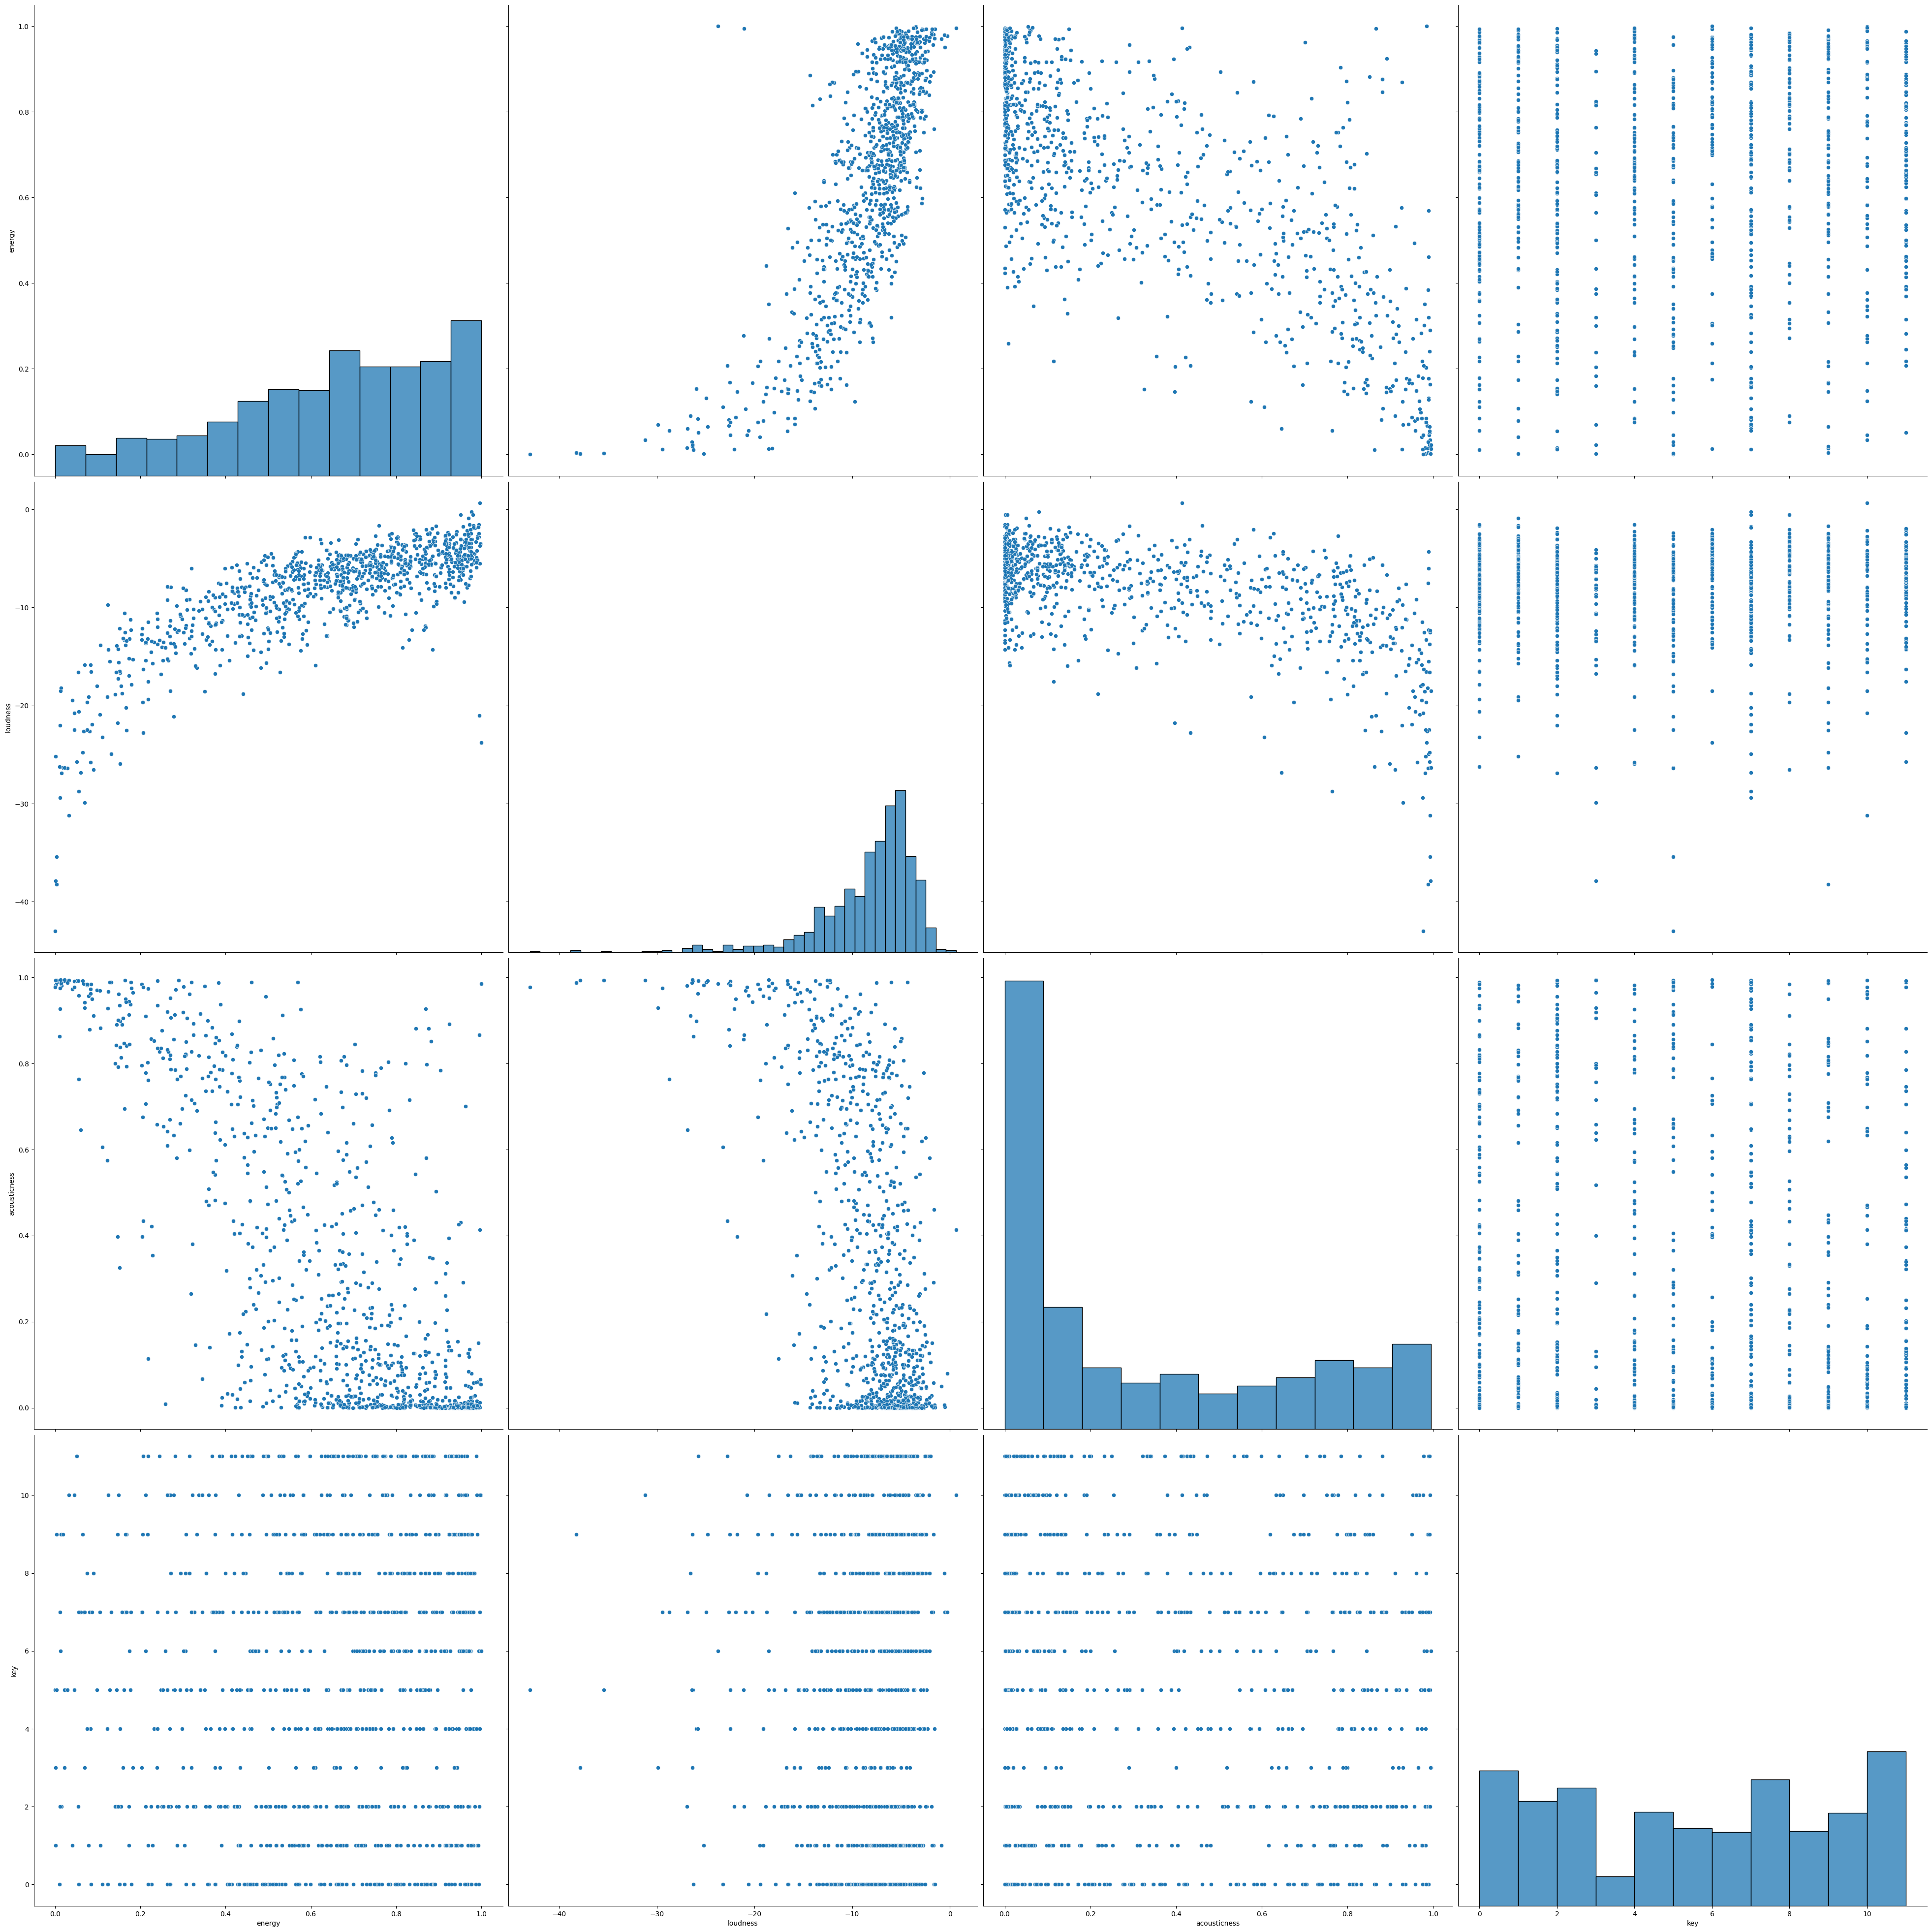

In [7]:
#fig , ax = plt.subplots(figsize =(10,7),dpi=100)
spotify.iloc[:,3:]
sns.pairplot(spotify.iloc[:,3:],size=10)

 We can observe an exponential relation in between loudness & energy, so if we linearise the model we might just find a lienar model 

# LINEAR REGRESSION - hell yeah
1. linearization
2. linear regression

<Axes: xlabel='loudness', ylabel='energy'>

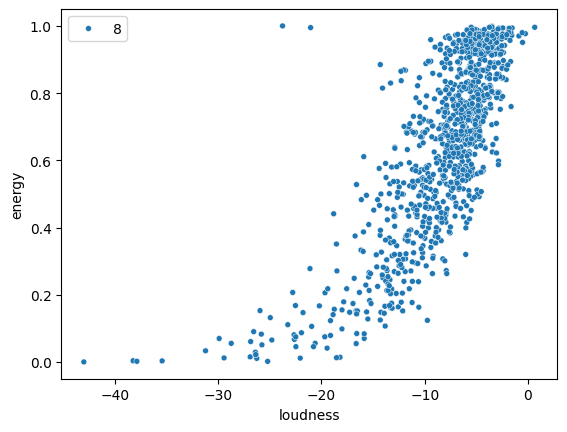

In [8]:
spotify_lr = spotify[["loudness","energy"]] # first we only take the two 
sns.scatterplot(data=spotify_lr,x='loudness',y='energy',size=8)

**1. Linearisation**

In [9]:
# to linearise , we'll apply a map to the y value
spotify_lr["energy"] = spotify_lr["energy"].map(np.log)
spotify_lr


/var/folders/xl/0wxp8zgx2wz1_sw2nyhksnr00000gn/T/ipykernel_46939/1081503018.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  spotify_lr["energy"] = spotify_lr["energy"].map(np.log)


,loudness,energy
0,-6.818,-0.339677
1,-4.231,-0.245901
2,-6.112,-0.423120
3,-5.406,-0.372514
4,-5.317,-0.585190
...,...,...
995,-6.442,-0.388608
996,-5.116,-0.346725
997,-3.908,-0.068279
998,-6.466,-0.375421


In [10]:
spotify_lr = spotify_lr.where(spotify_lr > -10)
spotify_lr = spotify_lr.dropna()
spotify_lr

,loudness,energy
0,-6.818,-0.339677
1,-4.231,-0.245901
2,-6.112,-0.423120
3,-5.406,-0.372514
4,-5.317,-0.585190
...,...,...
995,-6.442,-0.388608
996,-5.116,-0.346725
997,-3.908,-0.068279
998,-6.466,-0.375421


array([[1.        , 0.55815396],
       [0.55815396, 1.        ]])

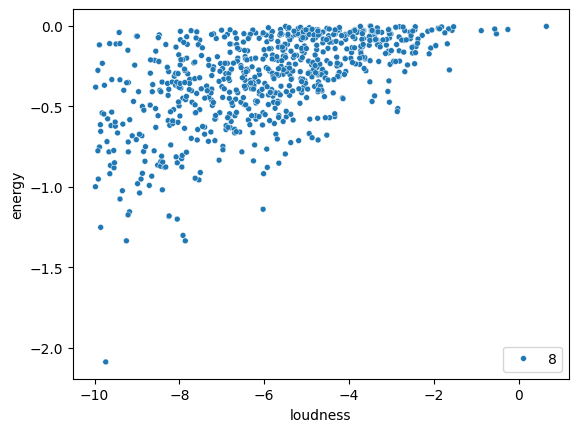

In [11]:
sns.scatterplot(data=spotify_lr,x='loudness',y='energy',size = 8)
np.corrcoef(spotify_lr.energy,spotify_lr.loudness)
# hey , the corr coefficient is 0.8 , it's good 


**2. Start of Linear Regression**

In [13]:
lr = st.linregress(x=spotify_lr.loudness,y=spotify_lr.energy)
a = lr.intercept
b = lr.slope
coef = [b,a]
boundaries = [-10,0]
lr

LinregressResult(slope=np.float64(0.07549324487760352), intercept=np.float64(0.11849676857128938), rvalue=np.float64(0.5581539567091749), pvalue=np.float64(3.5380382563154785e-61), stderr=np.float64(0.004153682755537372), intercept_stderr=np.float64(0.02579611431385809))

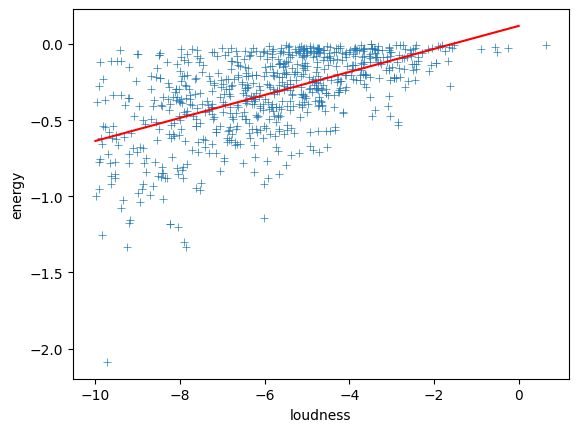

In [14]:
# lets plot this 
line = np.poly1d(coef)
sns.scatterplot(data=spotify_lr,x='loudness',y='energy',marker="+")
plt.plot(boundaries,line(boundaries),'r-')


where i stopped: removing one outlier , now it isn't correlatied 